In [1]:
###basic python ds libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns # for sophisticated visuals

### sklearn for simple ml
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
path_to_folder = '/content/drive/My Drive/Colab Notebooks/ML4Sc-Course/'
mpg_data = pd.read_csv(path_to_folder + 'auto-mpg.csv')
print (mpg_data.shape)

(398, 7)


original dataset can be found in the [UCI repo](https://archive.ics.uci.edu/dataset/9/auto+mpg), if you want to refer!

In [4]:
mpg_data.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model-year
0,18.0,8,307.0,130.0,3504,12.0,70
1,15.0,8,350.0,165.0,3693,11.5,70
2,18.0,8,318.0,150.0,3436,11.0,70
3,16.0,8,304.0,150.0,3433,12.0,70
4,17.0,8,302.0,140.0,3449,10.5,70


So we have a dataset where we have 398 rows (i.e. datapoints) and 7 features

In [5]:
## check the data types

mpg_data.dtypes

,0
mpg,float64
cylinders,int64
displacement,float64
horsepower,float64
weight,int64
acceleration,float64
model-year,int64


In [6]:
mpg_data.columns

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model-year'],
      dtype='object')

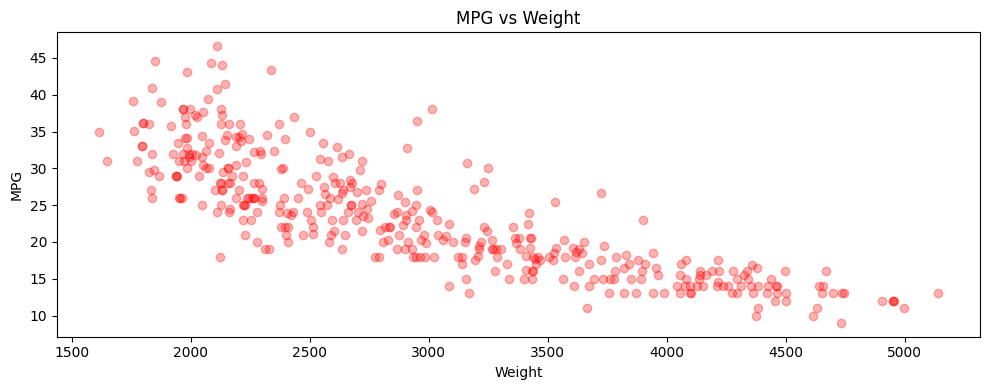

In [7]:
## let's check a similar plot to what was shown in the class

fig = plt.figure(figsize=(10, 4))
plt.plot(mpg_data['weight'], mpg_data['mpg'], marker='o', ls='none', color='red', alpha=0.3)
#plt.xscale('log') # uncomment this to see how it looks
plt.xlabel('Weight')
plt.ylabel('MPG')
plt.title('MPG vs Weight')
plt.tight_layout()
plt.show()

<Figure size 1000x400 with 0 Axes>

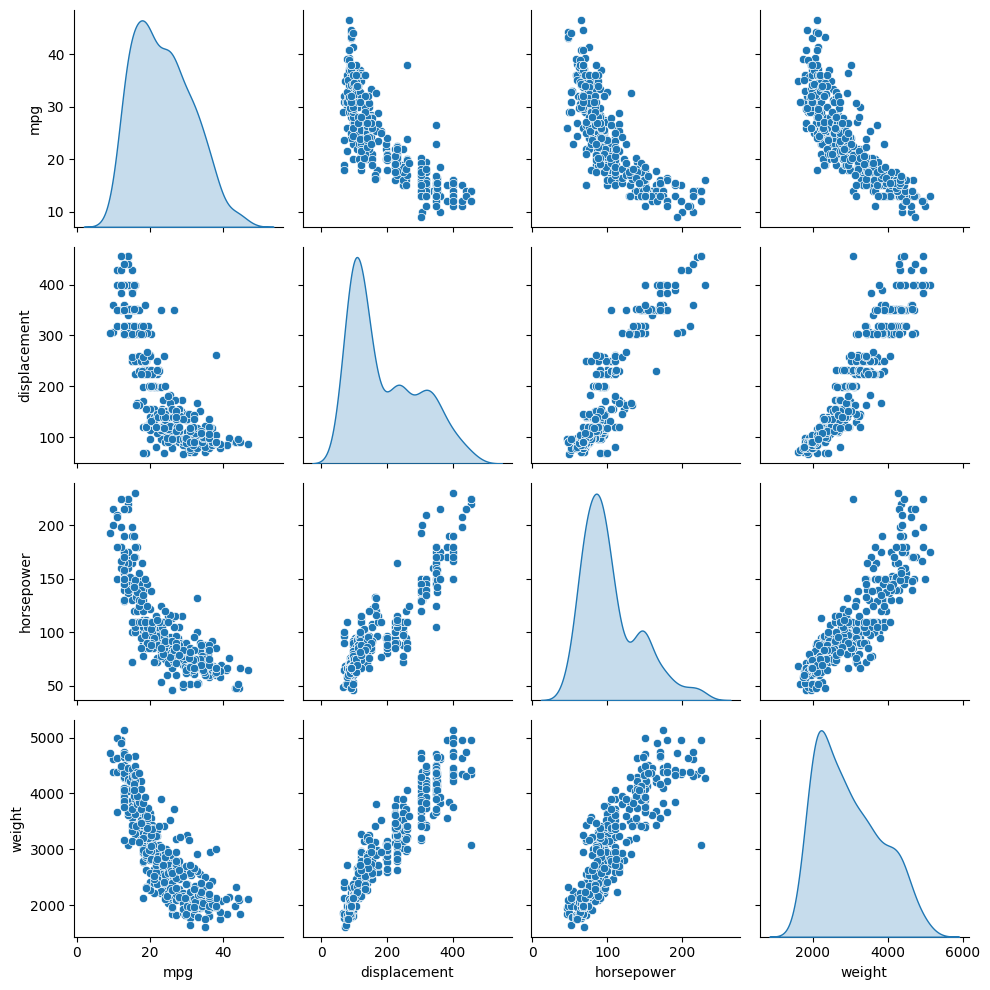

In [8]:
# But we also have several other features like horsepower, acceleration etc;
# let's make some joint plot

fig = plt.figure(figsize=(10, 4))
sns.pairplot(mpg_data[["mpg", "displacement", "horsepower", "weight"]], diag_kind="kde")
plt.tight_layout()
plt.show()


In [9]:
### let's first build the single variable linear regression step

X = np.log(mpg_data['weight'].values) # values turn dataframe to array
print (X.shape)
y = mpg_data['mpg'].values
print (y.shape)

(398,)
(398,)


but our sklearn library expect the feature dimension to be 2d now it is 1d

In [10]:
X = X.reshape(-1, 1)
print (X.shape)

(398, 1)


(318, 1)
(80, 1)
(318,)
(80,)
Model weight (slope): -23.7581
Model bias (intercept): 212.6461


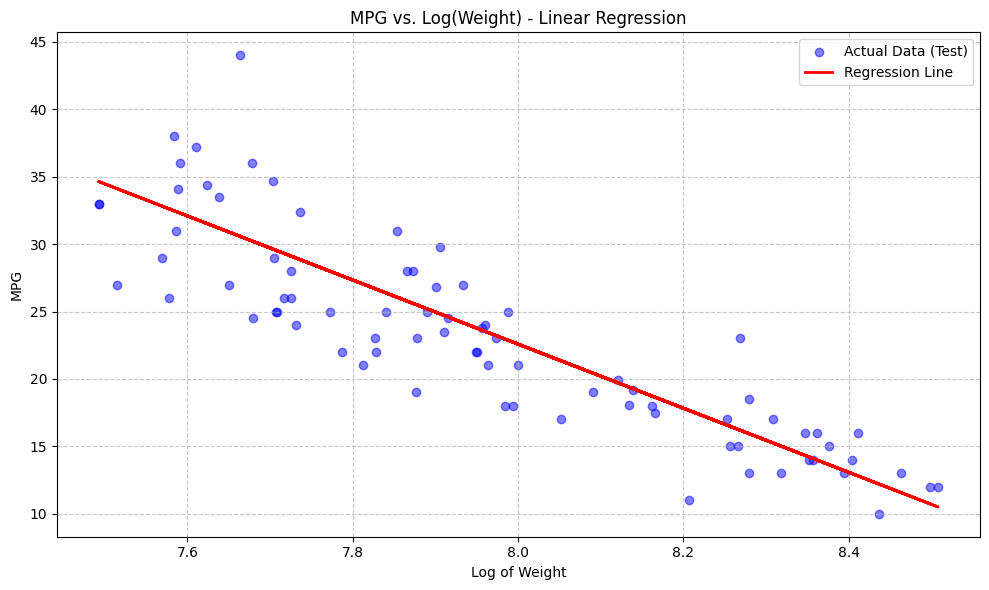

------------------------------
Mean Squared Error (MSE): 13.3520
Root Mean Squared Error (RMSE): 3.6540 mpg
R-squared Score: 0.7517


In [11]:
## now we randomly split the data in train and test set

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print (X_train.shape)
print (X_test.shape)

print (y_train.shape)
print (y_test.shape)

# initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# get back the weights (coefficients) and biases (intercept) # y = mx+c m: weights, c: biases
weight_val = model.coef_[0]
bias_val = model.intercept_

print(f"Model weight (slope): {weight_val:.4f}")
print(f"Model bias (intercept): {bias_val:.4f}")

# use this to predict on the dataset
y_pred = model.predict(X_test)


mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)



# 6. Visualization
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='blue', alpha=0.5, label='Actual Data (Test)')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line')
plt.xlabel('Log of Weight')
plt.ylabel('MPG')
plt.title('MPG vs. Log(Weight) - Linear Regression')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### finally check the overall error in test set

print("-" * 30)
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f} mpg")
print(f"R-squared Score: {r2:.4f}")

Looks good! How about we try now multivariable regression with not only log(weight) as a feature but we add 'horsepower', 'acceleration' as other variables?

However there is one small trouble! Horsepower column has '?' i.e. missing values; Simplest way to deal with that is drop these columns; so first we replace the non-numeric (i.e. '?', '/' etc) rows with 'NaN' and then drop them

In [12]:
mpg_data['horsepower'] = pd.to_numeric(mpg_data['horsepower'], errors='coerce')
mpg_data = mpg_data.dropna(subset=['horsepower'])

# use log of weight and other feats.
mpg_data['log_weight'] = np.log(mpg_data['weight'])
features = ['log_weight', 'horsepower', 'acceleration']

X = mpg_data[features]
y = mpg_data['mpg']

# same as before; random train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# use this multivariable data now
multi_model = LinearRegression()
multi_model.fit(X_train, y_train)

# check weights and biases
coeff_df = pd.DataFrame(multi_model.coef_, X.columns, columns=['Coefficient'])
print("Model Weights:")
print(coeff_df)
print(f"\nIntercept (Bias): {multi_model.intercept_:.4f}")

# predict and calculate error
y_pred = multi_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("-" * 30)
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f} mpg")
print(f"R-squared Score: {r2:.4f}")

Model Weights:
              Coefficient
log_weight     -18.473699
horsepower      -0.051622
acceleration    -0.029796

Intercept (Bias): 176.5212
------------------------------
Mean Squared Error (MSE): 18.7682
Root Mean Squared Error (RMSE): 4.3322 mpg
R-squared Score: 0.6383


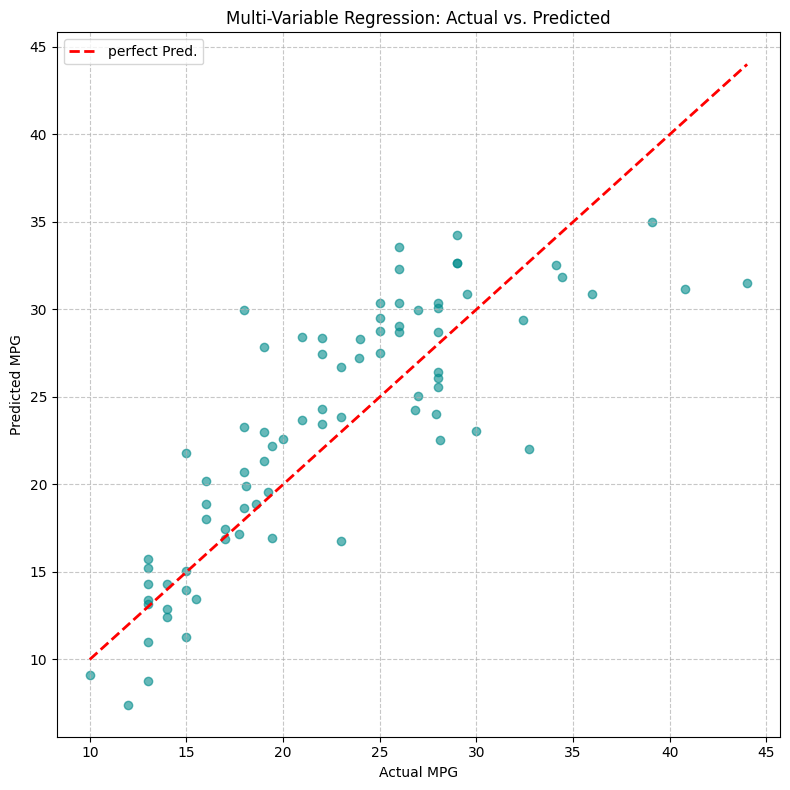

In [13]:
# now we can only plot actual and pred

plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.6, color='darkcyan')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='perfect Pred.') # Diagonal line
plt.xlabel('Actual MPG')
plt.ylabel('Predicted MPG')
plt.title('Multi-Variable Regression: Actual vs. Predicted')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()